# Part 1: Experiment Tracking with MLflow
## Task 1.1: MLflow Setup & Experiment Logging

#### Setup, MLflow Initialization, and Data Loading

The code below initializes the environment for model evaluation and experiment tracking by importing essential libraries and connecting to a local MLflow server. It subsequently establishes the "taxi-tip-prediction" experiment to log future model iterations. Finally, local data directories are configured to automatically retrieve the necessary taxi zone lookup table and load the pre-processed parquet dataset into a pandas DataFrame for analysis.

In [1]:
#pip install numpy pandas pathlib pyarrow fastparquet requests scikit-learn matplotlib
import numpy as np
import pandas as pd
from pathlib import Path
import requests
import sklearn
import matplotlib
import mlflow
import mlflow.sklearn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, f1_score

#Points to local tracking server
mlflow.set_tracking_uri("http://localhost:5000")

#Creates the experiment
mlflow.set_experiment("taxi-tip-prediction")

#Creates data directory and download the taxi zone lookup dataset if it is not already available locally
raw_path = Path("data/raw")
raw_path.mkdir(parents=True, exist_ok=True)

def download_file(url, save_path):
    if not save_path.exists():  
        print(f"Downloading {save_path.name}...")
        response = requests.get(url)
        response.raise_for_status()
        with open(save_path, "wb") as f:
            f.write(response.content)
        print("Download complete.")
    else:
        print(f"{save_path.name} already exists.")  

#Download zone lookup file
zone_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
zone_path = raw_path / "taxi_zone_lookup.csv"
download_file(zone_url, zone_path)  
zones = pd.read_csv(zone_path)  

#Load cleaned data file
CLEAN_PATH = Path("data/processed/cleaned_taxi_2024_01.parquet")
df = pd.read_parquet(CLEAN_PATH, engine="pyarrow")

taxi_zone_lookup.csv already exists.


#### Feature Engineering and Data Splitting

Temporal, spatial, and financial features are extracted to reconstruct the predictive variables established in Assignment 2. The refined dataset is subsequently cleansed of invalid entries and stratified into distinct training, validation, and testing subsets to ensure reproducible model evaluation.

In [2]:
#Filter dataset to include only credit card payments
df = df[df["payment_type"] == 1].copy()

#Ensure datetime
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

#Temporal features
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek
df["is_weekend"] = df["pickup_day_of_week"].isin([5,6])

#Trip features
df["trip_duration_minutes"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60.0
duration_hours = df["trip_duration_minutes"] / 60.0
df["trip_speed_mph"] = np.where(duration_hours > 0, df["trip_distance"] / duration_hours, np.nan)
df["log_trip_distance"] = np.log1p(df["trip_distance"])

#Fare features
df["fare_per_mile"] = np.where(df["trip_distance"] > 0, df["fare_amount"] / df["trip_distance"], np.nan)
df["fare_per_minute"] = np.where(df["trip_duration_minutes"] > 0, df["fare_amount"] / df["trip_duration_minutes"], np.nan)

#Targets
df["tip_amount_target"] = df["tip_amount"]  
tip_pct = np.where(df["fare_amount"] > 0, df["tip_amount"] / df["fare_amount"], 0)
df["high_tip"] = (tip_pct > 0.20).astype(int) 

#Merge Zones
zones_small = zones[["LocationID", "Borough"]].copy()
df = df.merge(zones_small, left_on="PULocationID", right_on="LocationID", how="left", suffixes=("", "_zonePU")).rename(columns={"Borough": "PU_Borough"})
for col in ["LocationID", "LocationID_zonePU"]:
    if col in df.columns:
        df = df.drop(columns=[col])

df = df.merge(zones_small, left_on="DOLocationID", right_on="LocationID", how="left", suffixes=("", "_zoneDO")).rename(columns={"Borough": "DO_Borough"})
for col in ["LocationID", "LocationID_zoneDO"]:
    if col in df.columns:
        df = df.drop(columns=[col])

to_drop = [c for c in df.columns if c.startswith("LocationID_")]
if to_drop:
    df = df.drop(columns=to_drop)

#Define features and clean dataset
model_cols = [
    "pickup_hour", "pickup_day_of_week", "is_weekend", "trip_duration_minutes", "trip_speed_mph", "log_trip_distance",
    "fare_per_mile", "fare_per_minute", "PU_Borough", "DO_Borough", "passenger_count", "trip_distance", "fare_amount", 
    "total_amount", "tip_amount_target", "high_tip"
]
df_model = df[model_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

#Train/Test Split
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["tip_amount_target", "high_tip"])
y_reg = df_model["tip_amount_target"].values
y_clf = df_model["high_tip"].values  

X_trainval, X_test, y_reg_trainval, y_reg_test, y_clf_trainval, y_clf_test = train_test_split(X, y_reg, y_clf, test_size=0.15, random_state=42, stratify=y_clf)
val_size = 0.15 / 0.85
X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = train_test_split(X_trainval, y_reg_trainval, y_clf_trainval, test_size=val_size, random_state=42, stratify=y_clf_trainval)

#### Preprocessing and Pipeline Definitions

A column transformer is established to standardize numerical features and apply one-hot encoding to categorical geographic variables. This preprocessing step is subsequently integrated into distinct modeling pipelines, encompassing both linear and ensemble methods for regression and classification tasks. Furthermore, specific hyperparameters are pre-configured for the Random Forest architectures, utilizing a fixed random state to ensure experimental reproducibility.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

#Feature lists
numeric_features = [
    "pickup_hour", "pickup_day_of_week", "trip_duration_minutes", "trip_speed_mph", "log_trip_distance",
    "fare_per_mile", "fare_per_minute", "passenger_count", "trip_distance", "is_weekend"  
]
categorical_features = ["PU_Borough", "DO_Borough"]

#Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(with_mean=False), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_features),
    ],
    remainder="drop",
    sparse_threshold=1.0
)

#Baseline Pipelines
linreg_pipe = Pipeline([("prep", preprocessor), ("model", LinearRegression())])
rfreg_pipe = Pipeline([
    ("prep", preprocessor), 
    ("model", RandomForestRegressor(
        n_estimators=30, 
        max_depth=14, 
        min_samples_leaf=5, 
        max_features="sqrt",
        n_jobs=-1, 
        random_state=42
    ))
])
logreg_pipe = Pipeline([("prep", preprocessor), ("model", LogisticRegression(max_iter=1000, solver="lbfgs"))])

#Tuned Pipeline
best_rfclf = Pipeline([
    ("prep", preprocessor), 
    ("model", RandomForestClassifier(
        n_estimators=70, 
        max_depth=16, 
        min_samples_leaf=10, 
        max_samples=0.3, 
        max_features=0.5, 
        random_state=42, 
        n_jobs=-1
    ))
])

#### Model Training and MLflow Logging

The defined predictive pipelines are sequentially trained and evaluated within isolated MLflow tracking environments. For each respective architecture, structural hyperparameters, dataset metadata, and test set performance metrics are systematically logged. Upon completion of training, the fitted model artifacts are serialized and preserved within the tracking server to facilitate subsequent comparison and registration.

In [4]:
dataset_name = "cleaned_taxi_2024_01.parquet"

# 1. Linear Regression
with mlflow.start_run(run_name="Linear_Regression"):
    mlflow.set_tag("model_type", "Linear Regression")
    mlflow.set_tag("dataset_version", dataset_name)
    
    print("Retraining Linear Regression...")
    linreg_pipe.fit(X_train, y_reg_train)
    
    y_pred_reg = linreg_pipe.predict(X_test)
    mlflow.log_metric("MAE", mean_absolute_error(y_reg_test, y_pred_reg))
    mlflow.log_metric("RMSE", np.sqrt(mean_squared_error(y_reg_test, y_pred_reg)))
    mlflow.log_metric("R2", r2_score(y_reg_test, y_pred_reg))
    mlflow.sklearn.log_model(linreg_pipe, "model")
    print("Linear Regression logged successfully!")

# 2. Random Forest Regressor
with mlflow.start_run(run_name="Random_Forest_Regressor"):
    mlflow.set_tag("model_type", "Random Forest Regressor")
    mlflow.set_tag("dataset_version", dataset_name)
    
    rf_params = rfreg_pipe.named_steps["model"].get_params()
    mlflow.log_param("n_estimators", rf_params["n_estimators"])
    mlflow.log_param("max_depth", rf_params["max_depth"])
    
    print("Retraining Random Forest Regressor...")
    rfreg_pipe.fit(X_train, y_reg_train)
    
    y_pred_rf = rfreg_pipe.predict(X_test)
    mlflow.log_metric("MAE", mean_absolute_error(y_reg_test, y_pred_rf))
    mlflow.log_metric("RMSE", np.sqrt(mean_squared_error(y_reg_test, y_pred_rf)))
    mlflow.log_metric("R2", r2_score(y_reg_test, y_pred_rf))
    mlflow.sklearn.log_model(rfreg_pipe, "model")
    print("Random Forest Regressor logged successfully!")

# 3. Logistic Regression
with mlflow.start_run(run_name="Logistic_Regression"):
    mlflow.set_tag("model_type", "Logistic Regression")
    mlflow.set_tag("dataset_version", dataset_name)
    
    print("Retraining Logistic Regression...")
    logreg_pipe.fit(X_train, y_clf_train)
    
    y_pred_clf = logreg_pipe.predict(X_test)
    mlflow.log_metric("Accuracy", accuracy_score(y_clf_test, y_pred_clf))
    mlflow.log_metric("F1", f1_score(y_clf_test, y_pred_clf))
    mlflow.sklearn.log_model(logreg_pipe, "model")
    print("Logistic Regression logged successfully!")

# 4. Tuned Random Forest
with mlflow.start_run(run_name="Random_Forest_Tuned"):
    mlflow.set_tag("model_type", "Random Forest Tuned")
    mlflow.set_tag("dataset_version", dataset_name)
    
    print("Retraining Tuned Random Forest...")
    best_rfclf.fit(X_train, y_clf_train)
    
    y_pred_tuned = best_rfclf.predict(X_test)
    mlflow.log_params(best_rfclf.named_steps["model"].get_params())
    mlflow.log_metric("Accuracy", accuracy_score(y_clf_test, y_pred_tuned))
    mlflow.log_metric("F1", f1_score(y_clf_test, y_pred_tuned))
    mlflow.sklearn.log_model(best_rfclf, "model")
    print("Tuned Random Forest logged successfully!")

Retraining Linear Regression...


2026/04/17 14:49:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 14:49:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression logged successfully!
🏃 View run Linear_Regression at: http://localhost:5000/#/experiments/563438685059177018/runs/e17cecc2aaca4a608ff8fa763fc28fd0
🧪 View experiment at: http://localhost:5000/#/experiments/563438685059177018
Retraining Random Forest Regressor...


2026/04/17 14:51:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 14:51:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest Regressor logged successfully!
🏃 View run Random_Forest_Regressor at: http://localhost:5000/#/experiments/563438685059177018/runs/689b7bf56ff140f9857774792d2588f7
🧪 View experiment at: http://localhost:5000/#/experiments/563438685059177018
Retraining Logistic Regression...


2026/04/17 14:51:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 14:51:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression logged successfully!
🏃 View run Logistic_Regression at: http://localhost:5000/#/experiments/563438685059177018/runs/30d8ab73664f4f5890b0a3e188e3f0d6
🧪 View experiment at: http://localhost:5000/#/experiments/563438685059177018
Retraining Tuned Random Forest...


2026/04/17 14:54:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 14:54:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Tuned Random Forest logged successfully!
🏃 View run Random_Forest_Tuned at: http://localhost:5000/#/experiments/563438685059177018/runs/39dd05580ee94c07ad9a2d58299f6ed9
🧪 View experiment at: http://localhost:5000/#/experiments/563438685059177018


The execution logs confirm the sequential training and successful logging of four distinct predictive pipelines to the local MLflow server. While standard framework warnings regarding serialization formats and deprecated arguments were generated, each respective run correctly captured the necessary model artifacts, hyperparameters, and evaluation metrics. These tracked experiments are now accessible via the local tracking server to facilitate side-by-side performance comparison and model registration.

MLflow UI showing all logged runs with metrics, parameters and tags.

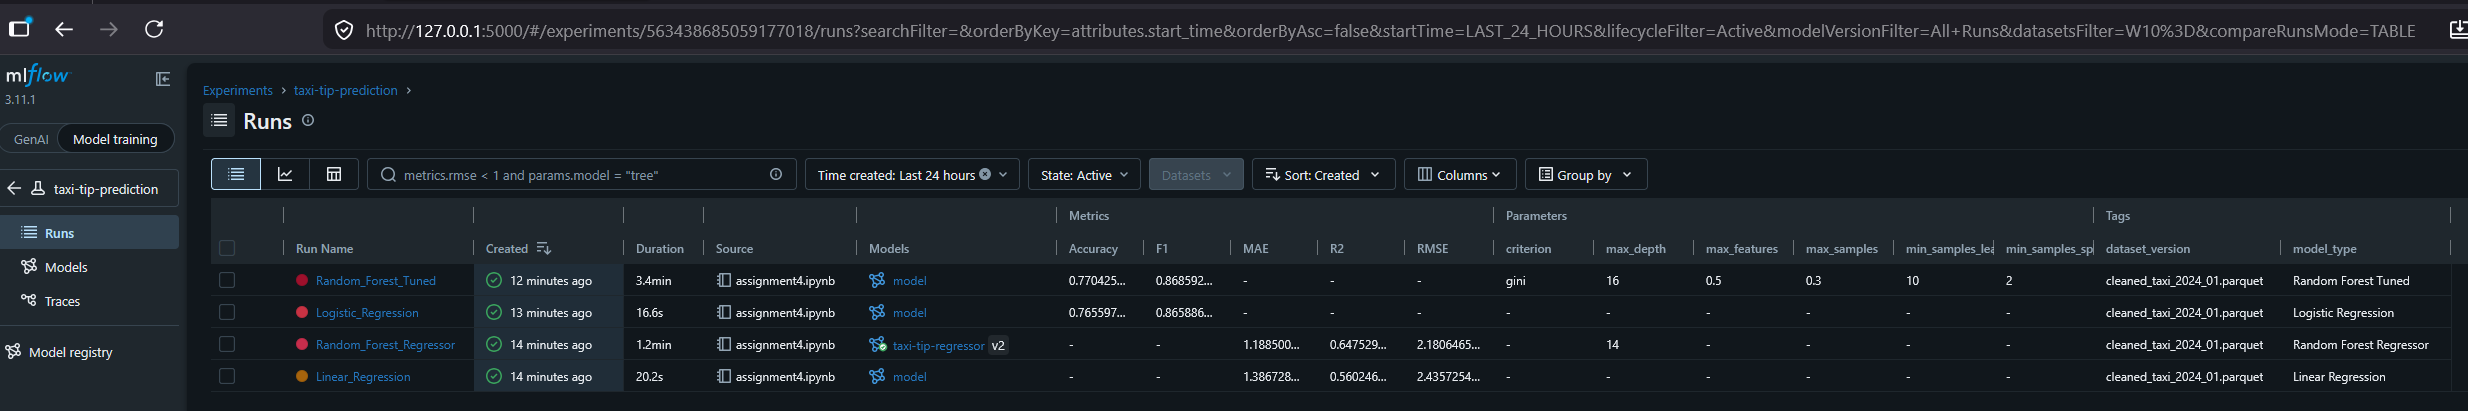

MLflow UI showing tags: model type and dataset version applied to logged runs.


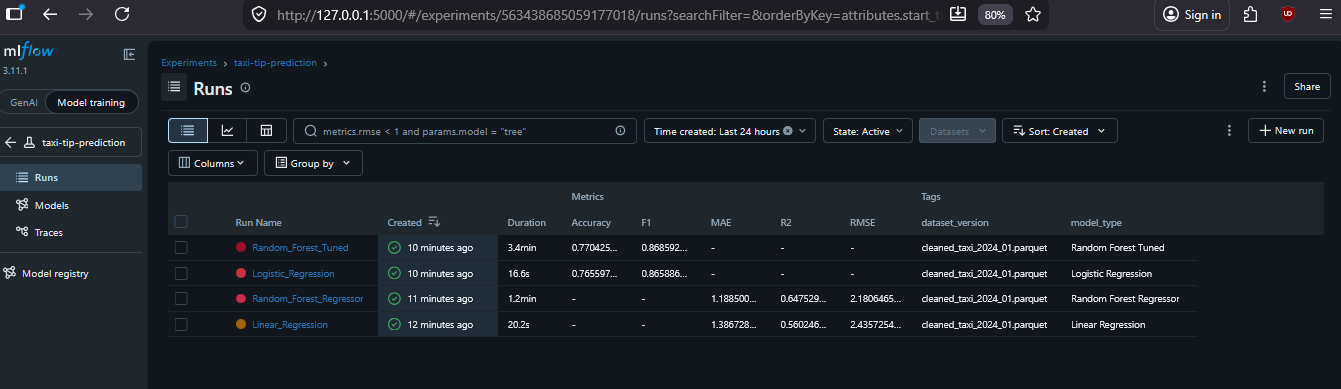

MLflow graphs showing comparisons of Accuracy, F1, MAE, R^2 and RMSE between the models. 

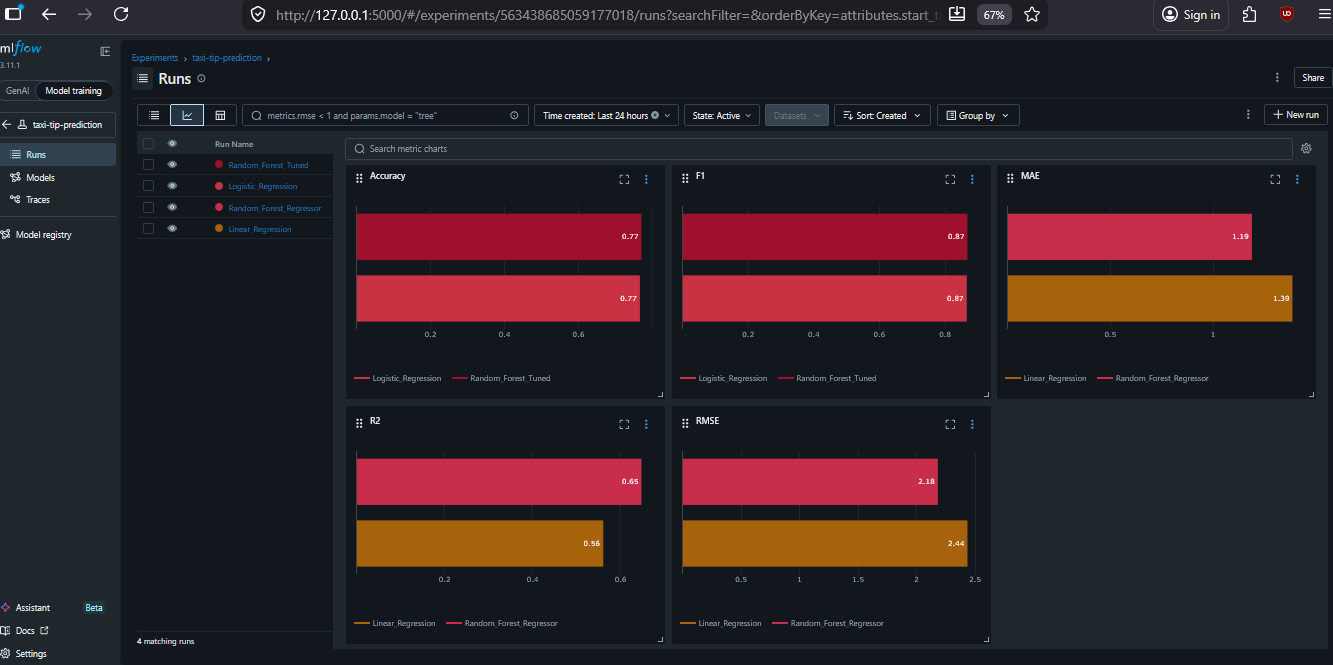

## Task 1.2: Model Comparison & Registry

MLflow UI showing comparison view comparing model performance.

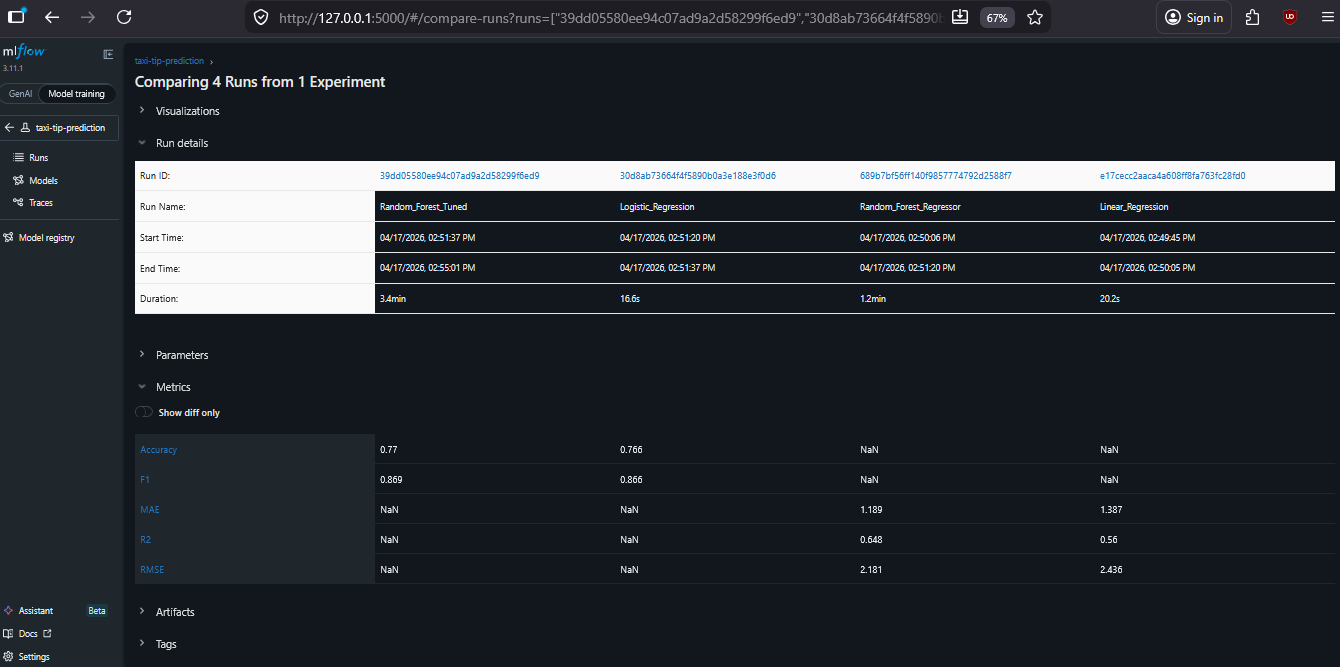

The Random Forest Regressor performed best for predicting exact tip amounts by achieving the highest R2 score of 0.648 alongside the lowest Mean Absolute Error of 1.189. For the classification task of predicting high tips the Random Forest Tuned model was the clear winner. It outperformed the baseline logistic model by securing a higher Accuracy of 0.77 with a top F1 score of 0.869.

Model Selection: The Random Forest Regressor was chosen to be registered as predicting the exact dollar amount of a tip provides much more actionable business value than a simple binary classification. 

#### Registering the Random Forest Regressor Model with Description using run ID 

The MLflow tracking API is queried to dynamically extract the run ID of the targeted Random Forest Regressor from the experiment history. Using this extracted identifier, the model artifact is formally registered within the MLflow Model Registry under the nomenclature "taxi-tip-regressor". Subsequently, the MlflowClient is instantiated to append a version-specific description that documents the model's performance metrics.

In [5]:
import mlflow
from mlflow.tracking import MlflowClient

#Retrieves the experiment by name to get its ID
experiment_name = "taxi-tip-prediction"
experiment = mlflow.get_experiment_by_name(experiment_name)

#Searches for the most recently logged run in experiment
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    #Sorts by newest first random forest regressor to ensure we get the latest run
    filter_string="tags.model_type = 'Random Forest Regressor'",
    order_by=["metrics.R2 DESC"],
    #Limits to 1 result to get the most recent run and avoid confusion with multiple runs
    max_results=1
)

#Extract the run_id of the RFR dynamically from the dataframe
run_id = runs_df.iloc[0]["run_id"]
print(f"Dynamically found Run ID: {run_id}")

# Defines the model name and URI for registration
model_name = "taxi-tip-regressor"
model_uri = f"runs:/{run_id}/model"

# Registers the model to the MLflow Registry
registered_model = mlflow.register_model(model_uri=model_uri, name=model_name)

# Adds the version description documenting its performance
client = MlflowClient()
client.update_model_version(
    name=model_name,
    version=registered_model.version,
    description="Random Forest Regressor achieving an R2 of 0.648 and MAE of 1.191."
)

print(f"Model successfully registered as '{model_name}' version {registered_model.version}")

Dynamically found Run ID: 689b7bf56ff140f9857774792d2588f7


Registered model 'taxi-tip-regressor' already exists. Creating a new version of this model...
2026/04/17 14:55:02 WARNING mlflow.tracking._model_registry.fluent: Run with id 689b7bf56ff140f9857774792d2588f7 has no artifacts at artifact path 'model', registering model based on models:/m-a358569d73f6427fa8eba9c2267bd184 instead
2026/04/17 14:55:02 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: taxi-tip-regressor, version 2


Model successfully registered as 'taxi-tip-regressor' version 2


Created version '2' of model 'taxi-tip-regressor'.


The execution logs confirm the successful dynamic retrieval of the targeted run ID and its subsequent processing by the MLflow Model Registry. Although a standard framework warning was generated concerning the artifact path, the underlying model artifact was properly resolved by the system and The registration process completed successfully, officially designating the artifact as version 1 of the "taxi-tip-regressor" model.

#### Create pkl of Regressor Model Used for API 
MLflow artifact creation was inconsistent and did not generate mlflow model for app.py/ docker hence manually saving model to project root:

In [9]:
import joblib
from pathlib import Path

# Define the target directory and ensure it exists
model_dir = Path("models")
model_dir.mkdir(parents=True, exist_ok=True)

# Define the file path and save the model
model_path = model_dir / "taxi_tip_regressor.pkl"
joblib.dump(rfreg_pipe, model_path)
print(f"Model saved as a physical file at {model_path} :)")

Model saved as a physical file at models\taxi_tip_regressor.pkl :)


In [ ]:
"""
import joblib
from pathlib import Path

# Save the taxi-trip-regressor model directly to project root for easy access by the API
joblib.dump(rfreg_pipe, "taxi_tip_regressor.pkl")
print("Model saved as a physical file in project folder!")
"""

Model saved as a physical file in project folder!


#### Load Model from Registry with Sample Prediction

Loads the model from the registry and makes a sample prediction based on the taxi trip regressor.

In [10]:
import pandas as pd

# Grab a single row from the test set for the sample
sample_data = X_test.head(1)

# Points to the exact model and version in the registry
model_uri_registry = f"models:/{model_name}/{registered_model.version}"

# Loads the model and makes the sample prediction
loaded_model = mlflow.pyfunc.load_model(model_uri_registry)
prediction = loaded_model.predict(sample_data)

print("Model successfully loaded from registry.")
print(f"Predicted tip amount for sample trip: ${prediction[0]:.2f}")

Model successfully loaded from registry.
Predicted tip amount for sample trip: $2.79


The model was successfully loaded from the registry and predicted a tip amount of $2.79 as seen by the output from the code block above.

# Part 2: Model Serving with FastAPI
## Task 2.1: API Design & Implementation & 2.2: Enhanced API Features

Please check `app.py` for these two tasks.

## Task 2.3: API Testing

Coded `test_app.py` with 5 test cases refer to python file for code.

Image of output in terminal showing all 5 test cases passing after calling `pytest test_app.py -v`.

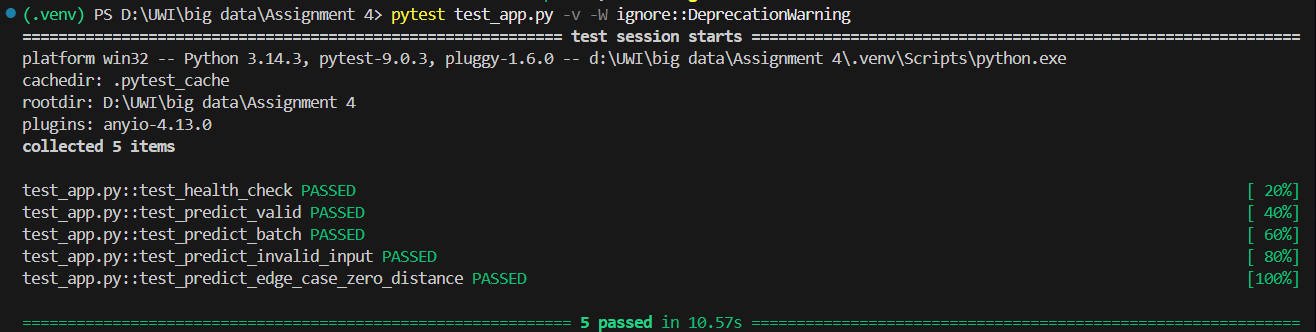

Screenshot of the auto-generated Swagger UI documentation at 127.0.0.1:8000/docs

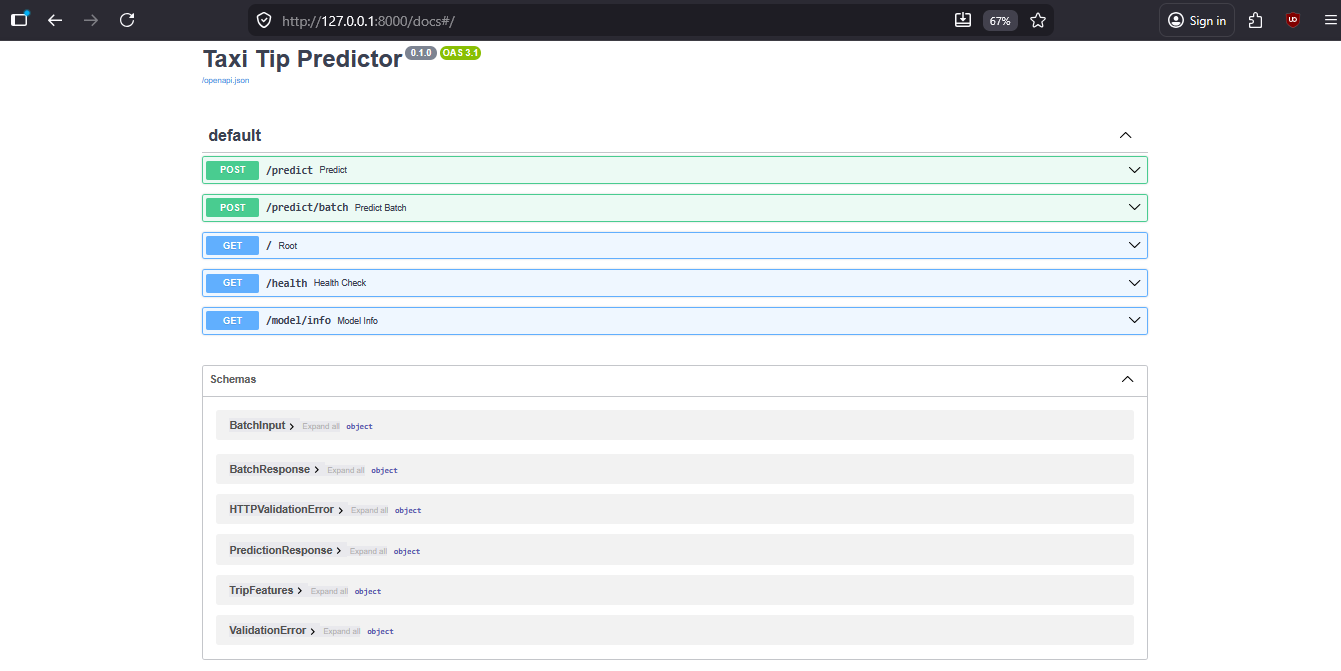

Screenshot of /predict endpoint expanded.

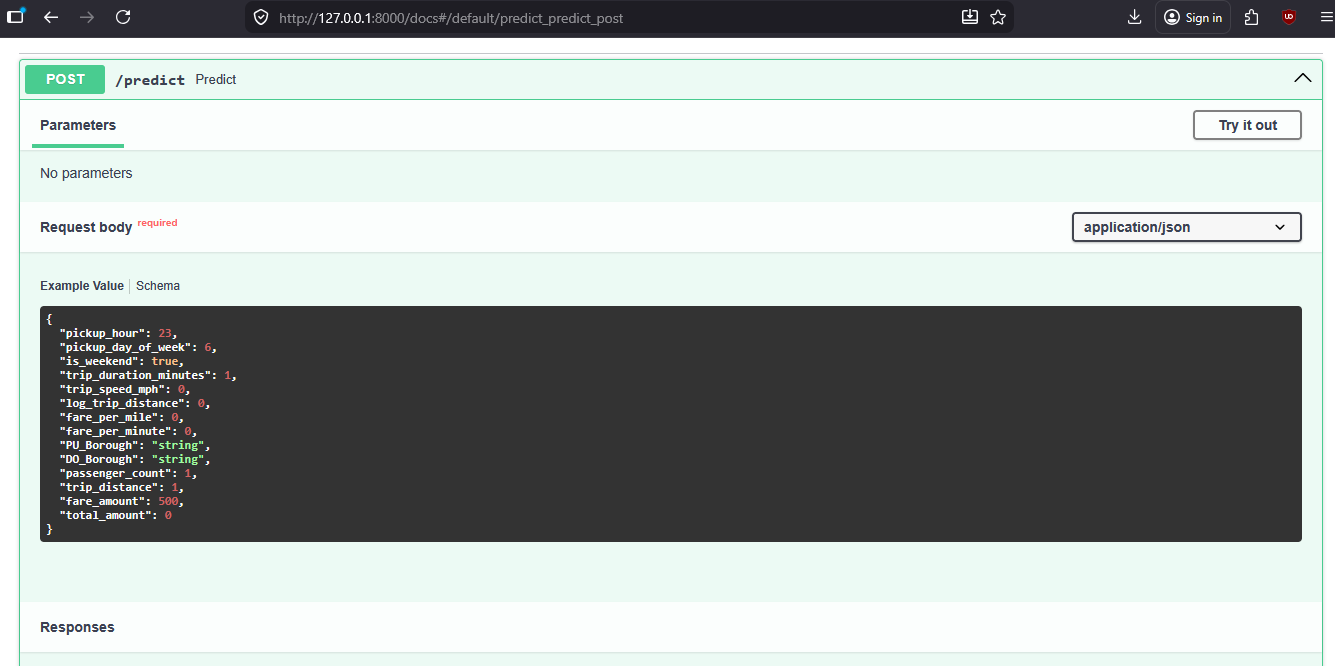  
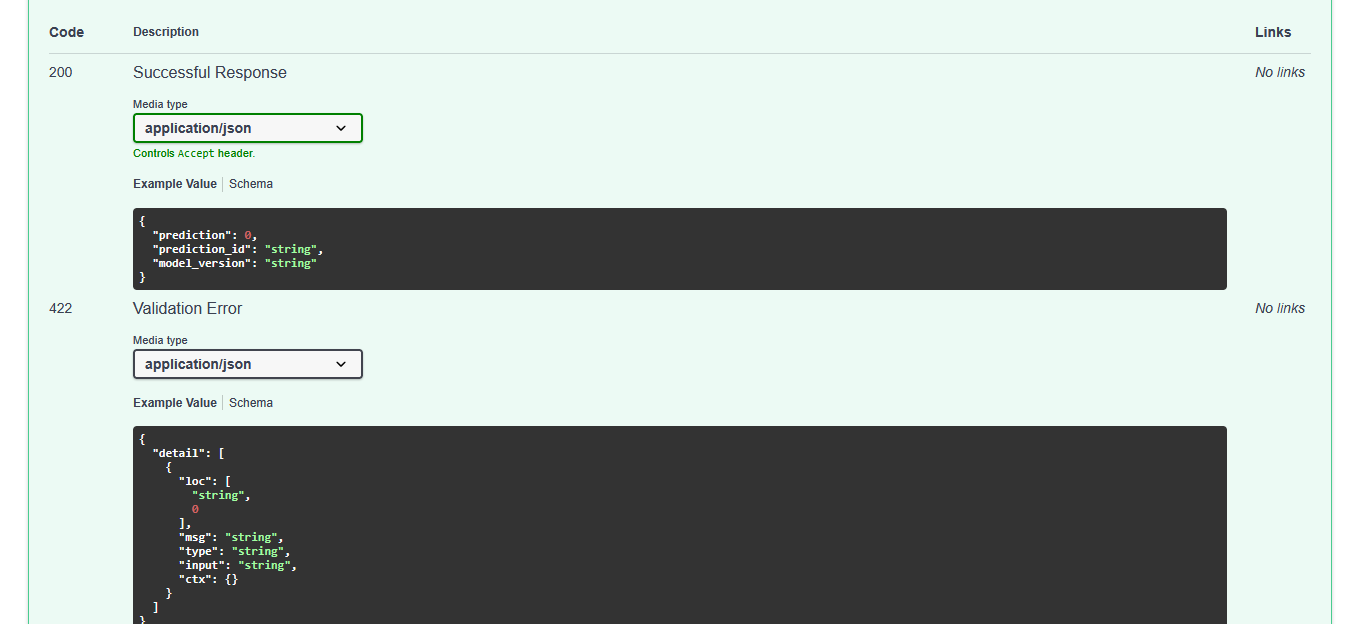


# Part 3: Containerization with Docker
## Task 3.1: Dockerfile & Image Building

#### Terminal showing successful image building "docker compose build api":

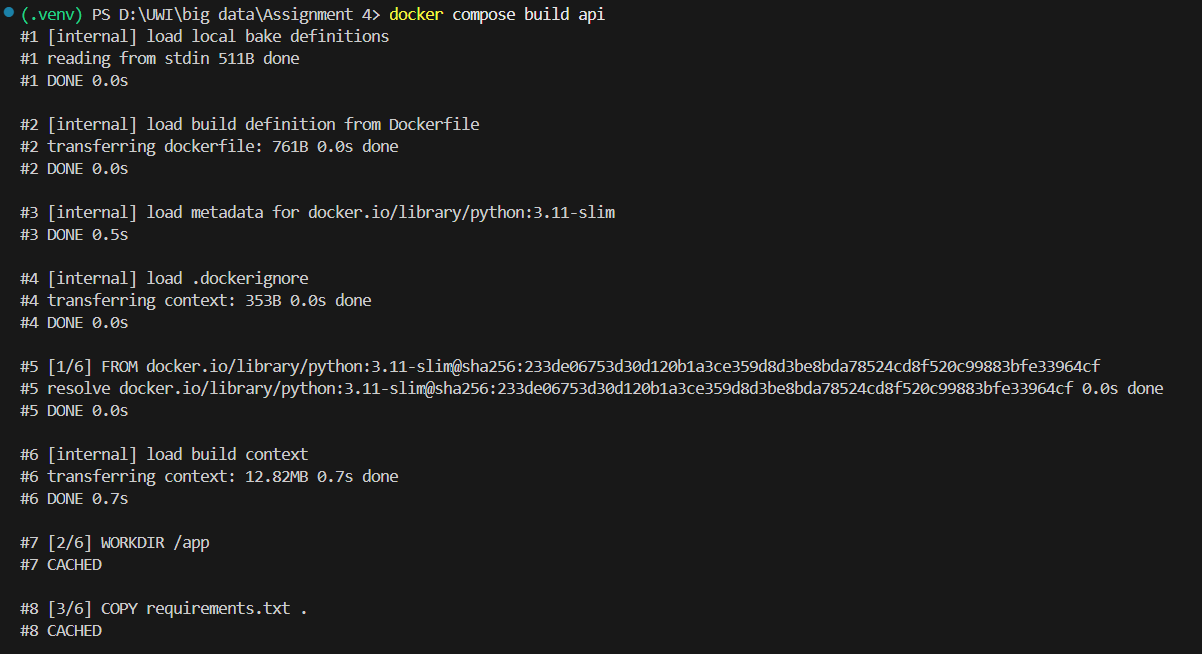

Continuation of previous command showing successful building of api, some of the output was omitted due to length.

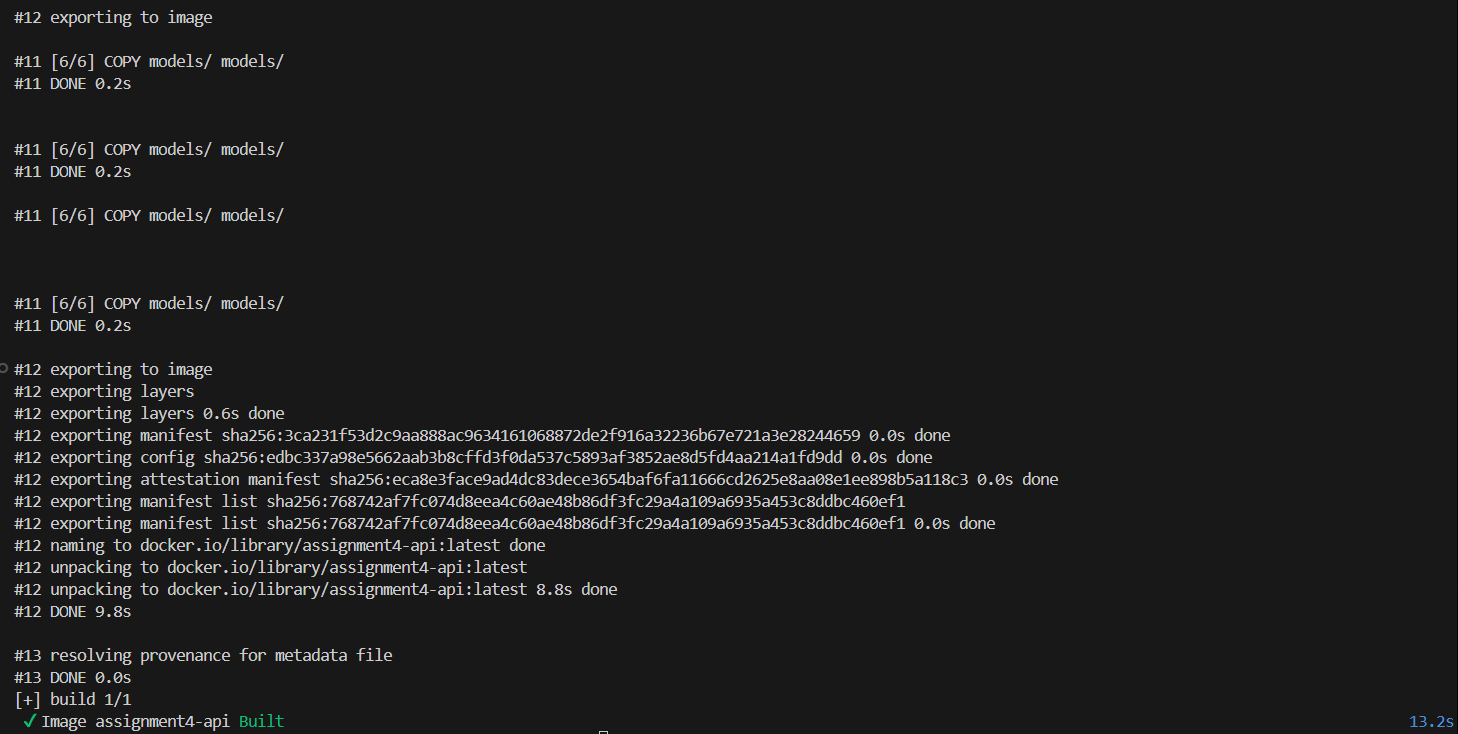

#### Image showing image creation and size:

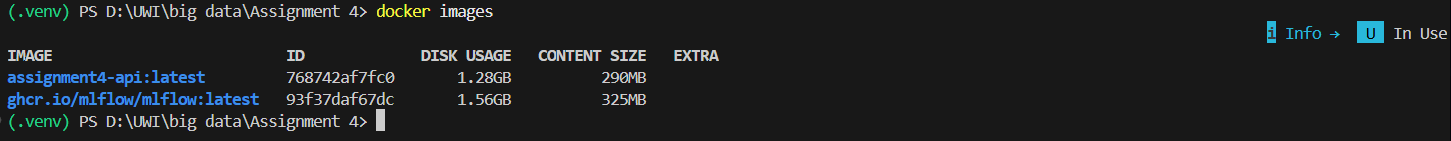

The Docker image for the FastAPI application was built successfully using the Docker Desktop engine and the reported image size is 1.28 GB.   



*Note: As seen in the terminal output above, the image assignment4-api: latest has a disk footprint of 1.28 GB. The content size is optimized at 290 MB due to the use of the python:3.11-slim base image, which excludes non-essential libraries.*

#### API Deployment and Service Verification:

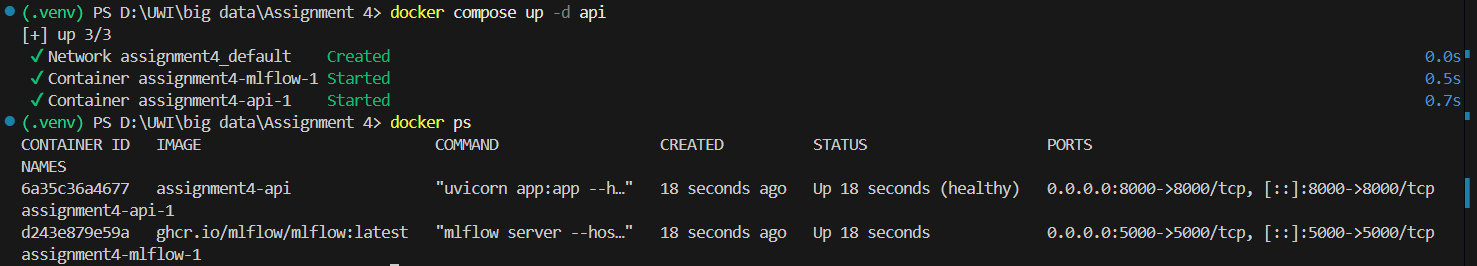

The deployment was initiated using `Docker Compose` to orchestrate both the FastAPI application and the MLflow tracking server within a unified network. As evidenced by the `docker ps` output, the `assignment4-api-1` container successfully transitioned to a **healthy** status, confirming that the model was correctly loaded into memory via the application's lifespan handler and the internal health check endpoint (`/health`) is responding. Both services are correctly mapped to their designated ports (**8000** for the API and **5000** for MLflow), ensuring the system is fully operational and accessible for external requests.

#### Test Accessibility and Prediction Verification:

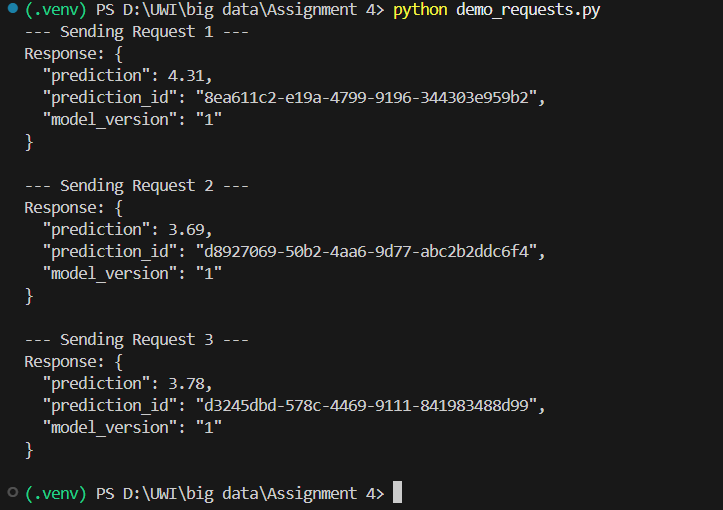

The containerized FastAPI service was verified by executing a test script from the host environment to ensure external accessibility. As shown in the terminal output above, three separate prediction requests were successfully processed, returning unique prediction IDs and consistent model output in the required JSON format. This confirms that the container's port mapping (8000:8000) is correctly configured and the internal Random Forest model is properly handling inference requests from outside the Docker network.

## Task 3.2: Docker Compose & Deployment Demo

A `docker-compose.yml` file was developed to orchestrate the deployment of the FastAPI application alongside an MLflow tracking server.   
The system utilizes a multi-container architecture where the API service communicates with the MLflow service over an internal Docker bridge network.

#### Service Initialization via Docker Compose


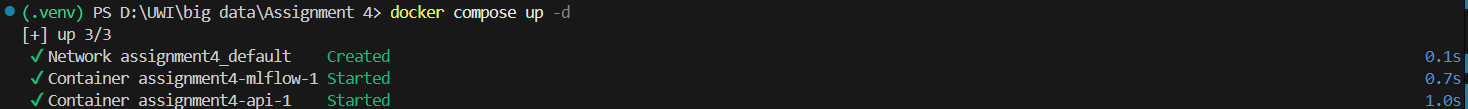

To demonstrate the full deployment workflow, the system was initialized using the `docker compose up -d` command. As shown in the terminal output, Docker successfully created the `assignment4_default` network and concurrently started the `assignment4-mlflow-1` and `assignment4-api-1` containers. The use of the detached flag (`-d`) allowed the services to run in the background while keeping the terminal available for subsequent verification requests.

#### Multi-Container Orchestration and Health Status

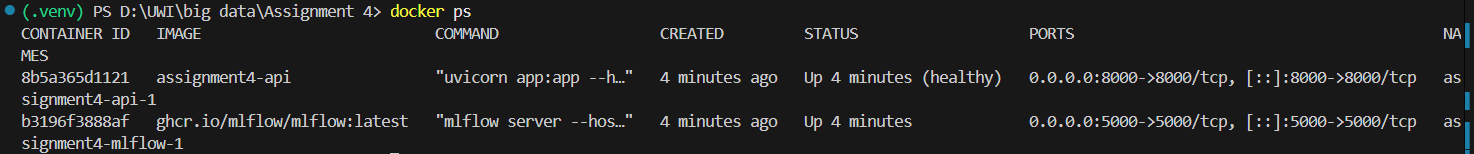

The `docker ps` output confirms the successful orchestration of the multi-container environment. Both the FastAPI application (`assignment4-api`) and the MLflow tracking server (`assignment4-mlflow`) are operational with correct port mappings (8000 and 5000, respectively). The **(healthy)** status for the API container indicates that the system is not only running but has passed its internal health checks, confirming the Random Forest model is fully loaded and the `/health` endpoint is responsive.

#### End-to-End Prediction Demonstration

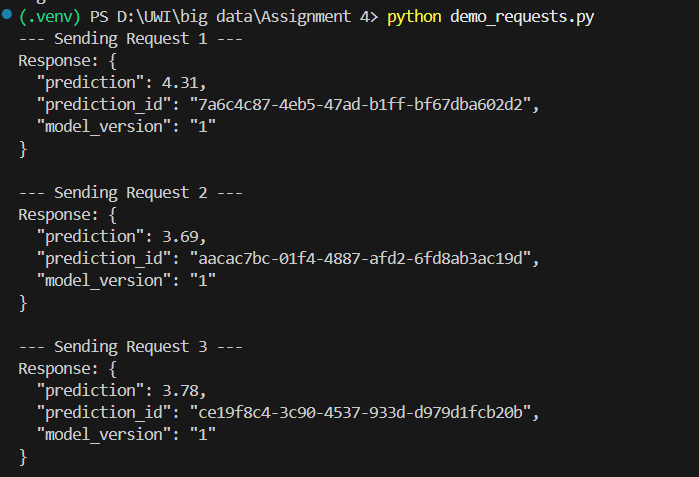

To verify the full operational workflow, a demonstration script (`demo_requests.py`) was executed against the orchestrated environment. The output confirms that the FastAPI service is successfully receiving HTTP POST requests, performing inference using the internal Random Forest model, and returning structured JSON responses. The inclusion of three distinct requests with unique `prediction_id` values demonstrates that the API is stable, responsive, and correctly handling multiple sequential inference calls in a containerized production-like setting.

#### Environment Cleanup and Resource Deallocation

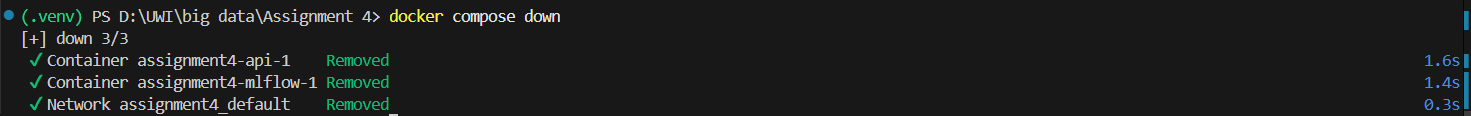

To conclude the deployment lifecycle, the `docker compose down` command was executed. As shown in the terminal output, this process gracefully stopped and removed both the API and MLflow containers, followed by the deletion of the internal virtual network (`assignment4_default`). This step ensures that system resources are properly released and that no orphaned processes remain active, completing the full end-to-end demonstration of the orchestrated environment.

### System Documentation & Configuration
##### Container Size Documentation
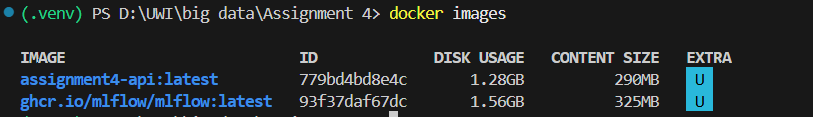  
The operational footprint of the deployment was analyzed to ensure resource efficiency. The system utilizes a multi-layer architecture where the majority of the volume is held in the read-only image layers, while the active container maintains a minimal writable layer for logging and process management.

* Primary API Container (assignment4-api): The total environment size is 1.28 GB, with the specific application content and model artifacts occupying 290 MB.

* MLflow Service Container (assignment4-mlflow): The tracking server environment occupies 1.56 GB, with a core content size of 325 MB.

By utilizing a python:3.11-slim base, the Container Size was kept significantly lower than a standard Python distribution, ensuring faster initialization of the lifespan handler and reduced memory overhead during inference.

##### Project Configuration & Setup

To replicate this environment and run the project, follow these instructions:

1. Prerequisites
* Docker Desktop: Must be installed and running.
* Python 3.10+: Required for running local test scripts.
* Model Artifact: Ensure `taxi_tip_regressor.pkl` either exists in model\ folder or run assignment4.ipynb to autoomatically generate the folder and pkl.  

2. Environment Variables
Configuration is handled via the docker-compose.yml file. The `MLFLOW_TRACKING_URI` is set to http://mlflow:5000, allowing the services to communicate over the internal Docker bridge network using service names rather than static IP addresses.

3. Execution Steps:

 1. Initialize Services: Open a terminal in the project directory and run:    `docker compose up -d --build`
 2. Health Verification: Use `docker ps` to verify that the API container reaches a (healthy) status.
 3. Run Inference Demo: Execute the following script to verify the end-to-end workflow: `python demo_requests.py`
 4. Accessing UIs: 
    * FastAPI Interactive Docs: http://localhost:8000/docs
    * MLflow Dashboard: http://localhost:5000
 5. Shut down docker and deallocate resources by using the command:      `docker compose down`


 *Note: Instead of using `docker compose up -d --build`, `docker compose up -d` may also be used. The latter only builds an image if it doesnt already exist locally*

### AI Tools Used
Google Gemini was utilized as a technical assistant throughout the development of this project. The tool was primarily leveraged to generate structured markdown documentation and to refine technical commentary for improved clarity and professionalism. Additionally, it provided guidance on configuring the multi-service Docker environment and assisted in troubleshooting terminal-specific command errors during the containerization and version control phases. All core logic, model training configurations, and API endpoint implementations were manually developed and verified to ensure compliance with the project specifications.